# 5. RFM анализ клиентов

## Цели:
- Сегментация клиентов по RFM (Recency, Frequency, Monetary)
- Анализ пожизненной ценности клиентов (LTV)
- Разработка стратегии удержания и мотивации
- Выявление ценных и проблемных сегментов

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')

In [2]:
# Настройка путей
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.rfm_analyzer import RFMAnalyzer

In [3]:
# Загрузка данных
print("ЗАГРУЗКА ДАННЫХ ДЛЯ RFM АНАЛИЗА...")
processed_data_path = project_root / 'data' / 'processed' / 'merged_data.csv'

if processed_data_path.exists():
    df = pd.read_csv(processed_data_path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    
    # Проверяем наличие клиентских данных
    if 'customer_id' not in df.columns:
        print("⚠ ВНИМАНИЕ: Отсутствует колонка customer_id")
        # Создаем временные customer_id на основе order_id
        df['customer_id'] = df['order_id'].astype(str) + '_temp'
        print("Созданы временные customer_id")
    
    print(f"Загружено {len(df)} записей")
    print(f"Уникальных клиентов: {df['customer_id'].nunique()}")
    print(f"Период данных: {df['date'].min()} - {df['date'].max()}")
else:
    print("❌ Файл с обработанными данными не найден")

ЗАГРУЗКА ДАННЫХ ДЛЯ RFM АНАЛИЗА...
Загружено 2366 записей
Уникальных клиентов: 861
Период данных: 2025-01-01 00:00:00 - 2025-09-28 00:00:00


In [4]:
# Инициализация RFM анализатора
print("ИНИЦИАЛИЗАЦИЯ RFM АНАЛИЗАТОРА...")

try:
    rfm_analyzer = RFMAnalyzer(df)
    print("✅ Анализатор успешно инициализирован")
except Exception as e:
    print(f"❌ Ошибка инициализации анализатора: {e}")

ИНИЦИАЛИЗАЦИЯ RFM АНАЛИЗАТОРА...
✅ Анализатор успешно инициализирован


In [5]:
# 1. РАСЧЕТ RFM МЕТРИК
print("\n" + "="*60)
print("РАСЧЕТ RFM МЕТРИК")
print("="*60)

rfm_data = rfm_analyzer.calculate_rfm()

print("Статистика RFM метрик:")
print(rfm_data[['recency', 'frequency', 'monetary']].describe())

print(f"\nОбщая статистика:")
print(f"• Всего клиентов: {len(rfm_data)}")
print(f"• Средний реценси: {rfm_data['recency'].mean():.1f} дней")
print(f"• Средняя частота: {rfm_data['frequency'].mean():.1f} покупок")
print(f"• Средний чек на клиента: {rfm_data['monetary'].mean():.0f} ₽")


РАСЧЕТ RFM МЕТРИК
Дата анализа RFM: 2025-09-28 00:00:00
Проанализировано клиентов: 861
Уникальные значения frequency: [ 1  4  5  2  3  6  7  8  9 10]
Ошибка в frequency bins: Bin labels must be one fewer than the number of bin edges
Статистика RFM метрик:
          recency   frequency      monetary
count  861.000000  861.000000    861.000000
mean    84.006969    2.734030  13601.304297
std     69.151031    1.537929  11594.446855
min      0.000000    1.000000    300.000000
25%     27.000000    2.000000   5580.000000
50%     65.000000    2.000000  10470.000000
75%    126.000000    4.000000  19740.000000
max    269.000000   10.000000  99900.000000

Общая статистика:
• Всего клиентов: 861
• Средний реценси: 84.0 дней
• Средняя частота: 2.7 покупок
• Средний чек на клиента: 13601 ₽


In [6]:
# 2. СЕГМЕНТАЦИЯ КЛИЕНТОВ
print("\n" + "="*60)
print("СЕГМЕНТАЦИЯ КЛИЕНТОВ")
print("="*60)

segments = rfm_analyzer.segment_customers()

print("Распределение по сегментам:")
print(segments[['count', 'percentage', 'monetary', 'frequency', 'recency']])


СЕГМЕНТАЦИЯ КЛИЕНТОВ
Распределение по сегментам:
                          count  percentage  monetary  frequency  recency
segment                                                                  
High Risk High Value          1         0.1  77700.00       7.00   111.00
Champions                    12         1.4  44294.50       7.67    19.58
235                          11         1.3  35241.82       5.18   114.82
Loyal Customers              82         9.5  27038.05       5.35    31.27
325                          22         2.6  26846.55       3.59    62.86
High Value New Customers    106        12.3  22985.40       3.17    20.28
315                           1         0.1  22200.00       2.00    50.00
Cannot Lose Them             73         8.5  19350.00       2.81   140.56
324                          28         3.3  17848.14       3.36    69.04
234                           3         0.3  16966.67       5.00   108.00
314                          11         1.3  14165.45       2.

In [7]:
# 3. АНАЛИЗ LTV (ПОЖИЗНЕННОЙ ЦЕННОСТИ)
print("\n" + "="*60)
print("АНАЛИЗ ПОЖИЗНЕННОЙ ЦЕННОСТИ КЛИЕНТОВ (LTV)")
print("="*60)

ltv_analysis = rfm_analyzer.analyze_customer_lifetime_value()

if ltv_analysis is not None:
    print("LTV по сегментам:")
    print(ltv_analysis[['count', 'avg_ltv', 'total_ltv', 'revenue_share']])
    
    # Анализ концентрации выручки
    top_segments_ltv = ltv_analysis.head(3)
    top_revenue_share = top_segments_ltv['revenue_share'].sum()
    print(f"\n💎 КОНЦЕНТРАЦИЯ ВЫРУЧКИ:")
    print(f"Топ-3 сегмента приносят {top_revenue_share:.1f}% выручки")


АНАЛИЗ ПОЖИЗНЕННОЙ ЦЕННОСТИ КЛИЕНТОВ (LTV)
LTV по сегментам:
                          count   avg_ltv  total_ltv  revenue_share
segment                                                            
High Risk High Value          1  77700.00      77700            0.7
Champions                    12  44294.50     531534            4.5
235                          11  35241.82     387660            3.3
Loyal Customers              82  27038.05    2217120           18.9
325                          22  26846.55     590624            5.0
High Value New Customers    106  22985.40    2436452           20.8
315                           1  22200.00      22200            0.2
Cannot Lose Them             73  19350.00    1412550           12.1
324                          28  17848.14     499748            4.3
234                           3  16966.67      50900            0.4
314                          11  14165.45     155820            1.3
113                          24  10827.42     259858  

In [8]:
# 4. СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ
print("\n" + "="*60)
print("СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО СЕГМЕНТАМ")
print("="*60)

recommendations = rfm_analyzer.get_segment_recommendations()

print("РЕКОМЕНДАЦИИ ПО РАБОТЕ С СЕГМЕНТАМИ:")
for segment, info in recommendations.items():
    if segment in segments.index:
        segment_data = segments.loc[segment]
        print(f"\n🎯 {segment} ({segment_data['count']} клиентов, {segment_data['percentage']}%):")
        print(f"   Описание: {info['description']}")
        print(f"   Цель: {info['goal']}")
        print(f"   Действия: {', '.join(info['actions'][:2])}")


СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО СЕГМЕНТАМ
РЕКОМЕНДАЦИИ ПО РАБОТЕ С СЕГМЕНТАМИ:

🎯 Champions (12.0 клиентов, 1.4%):
   Описание: Ваши лучшие клиенты
   Цель: Удержать и увеличить лояльность
   Действия: Персональные предложения, Программа лояльности

🎯 Loyal Customers (82.0 клиентов, 9.5%):
   Описание: Постоянные лояльные клиенты
   Цель: Повысить до Champions
   Действия: Перекрестные продажи, Скидки за лояльность

🎯 New Customers (162.0 клиентов, 18.8%):
   Описание: Недавно присоединившиеся клиенты
   Цель: Повысить частоту покупок
   Действия: Приветственная программа, Образовательный контент

🎯 Potential Loyalists (94.0 клиентов, 10.9%):
   Описание: Клиенты с потенциалом роста
   Цель: Увеличить частоту и сумму покупок
   Действия: Персонализированные рекомендации, Стимулы для повторных покупок

🎯 High Value New Customers (106.0 клиентов, 12.3%):
   Описание: Новые клиенты с высокими чеками
   Цель: Быстро перевести в лояльные
   Действия: VIP обслуживание, Персональный менеджер


In [9]:
# 5. АНАЛИЗ УДЕРЖАНИЯ КЛИЕНТОВ
print("\n" + "="*60)
print("АНАЛИЗ УДЕРЖАНИЯ И ПОТЕРЬ КЛИЕНТОВ")
print("="*60)

retention_insights = rfm_analyzer.get_customer_retention_insights()

if retention_insights:
    print("📊 СТАТИСТИКА УДЕРЖАНИЯ:")
    print(f"• Всего клиентов: {retention_insights['total_customers']}")
    print(f"• Утерянные клиенты: {retention_insights['lost_customers_count']} ({retention_insights['lost_customers_percentage']}%)")
    print(f"• Клиенты в группе риска: {retention_insights['at_risk_count']} ({retention_insights['at_risk_percentage']}%)")
    print(f"• Премиум сегменты: {retention_insights['premium_segments_count']} ({retention_insights['premium_segments_percentage']}%)")
    
    # Расчет общего риска потерь
    total_risk = retention_insights['lost_customers_percentage'] + retention_insights['at_risk_percentage']
    print(f"• Общий риск потерь: {total_risk:.1f}% клиентов")


АНАЛИЗ УДЕРЖАНИЯ И ПОТЕРЬ КЛИЕНТОВ
📊 СТАТИСТИКА УДЕРЖАНИЯ:
• Всего клиентов: 861
• Утерянные клиенты: 0 (0.0%)
• Клиенты в группе риска: 176 (20.4%)
• Премиум сегменты: 330 (38.3%)
• Общий риск потерь: 20.4% клиентов



ВИЗУАЛИЗАЦИЯ RFM АНАЛИЗА


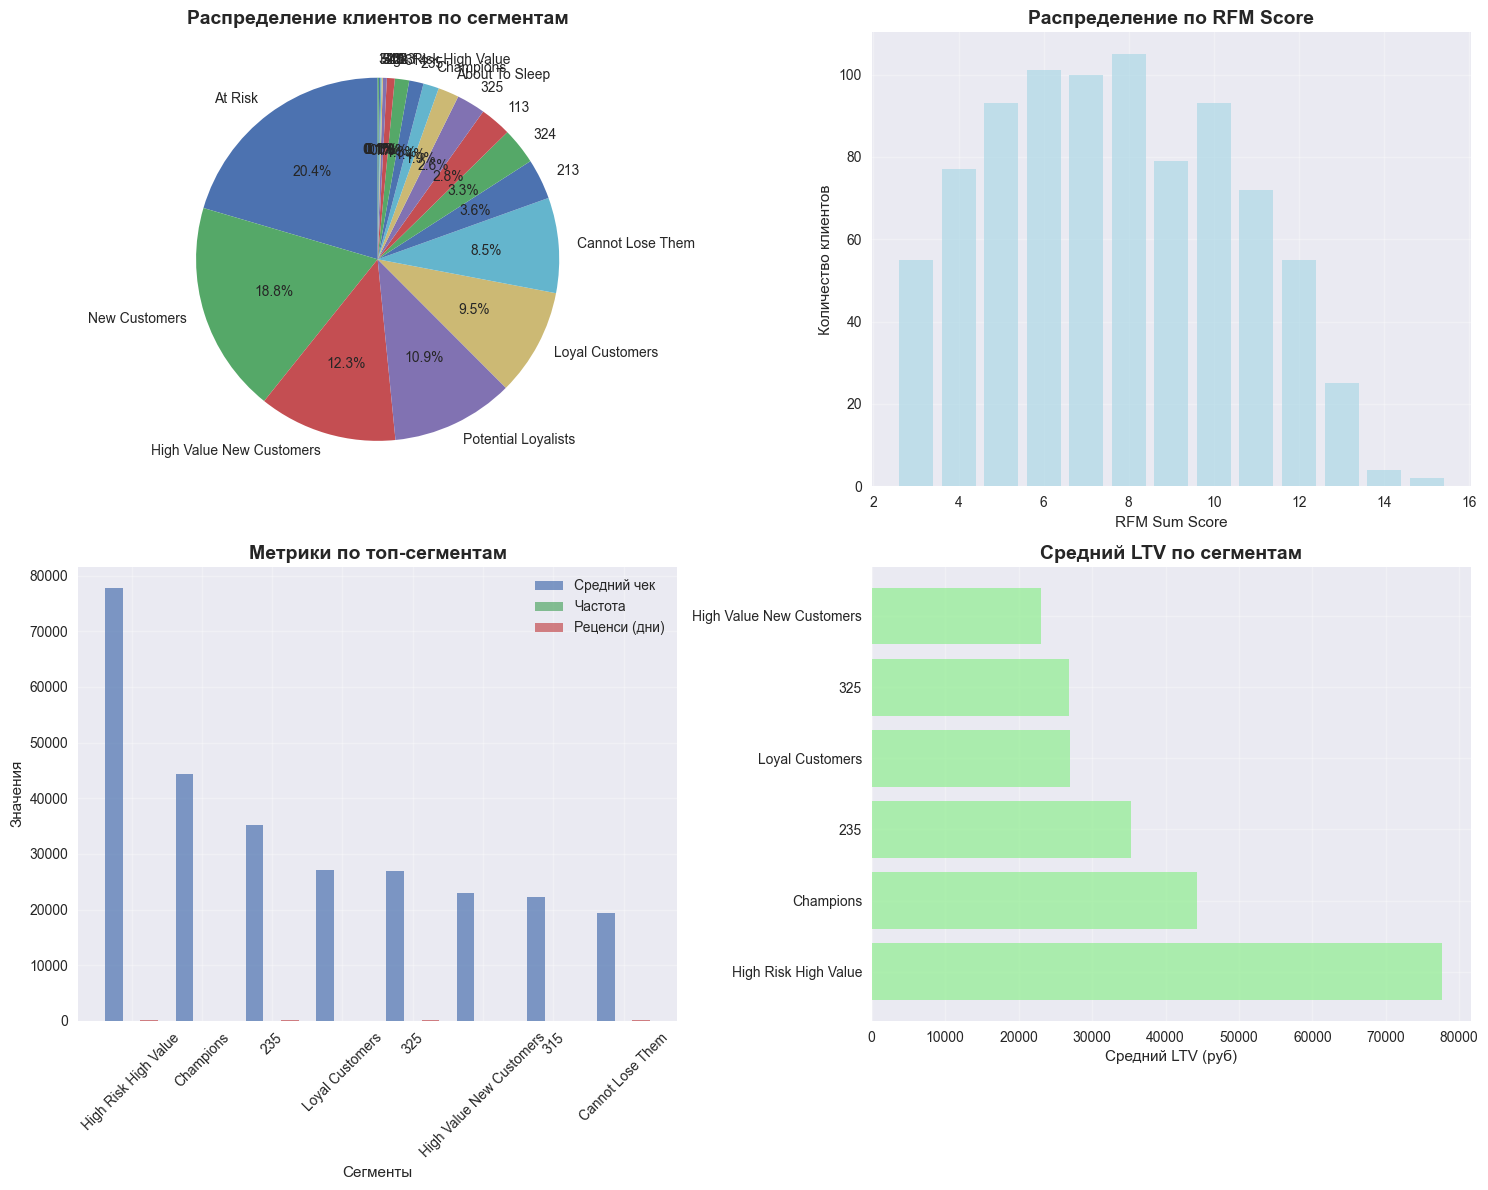

In [10]:
# 6. ВИЗУАЛИЗАЦИЯ RFM АНАЛИЗА
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ RFM АНАЛИЗА")
print("="*60)

rfm_analyzer.plot_rfm_analysis()

In [11]:
# 7. ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ")
print("="*60)

# Анализ чемпионов
champions = rfm_data[rfm_data['segment'] == 'Champions']
if not champions.empty:
    print(f"🏆 ЧЕМПИОНЫ: {len(champions)} клиентов")
    print(f"• Средний LTV: {champions['monetary'].mean():.0f} ₽")
    print(f"• Средняя частота: {champions['frequency'].mean():.1f} покупок")
    print(f"• Средний реценси: {champions['recency'].mean():.1f} дней")
    
    # Топ-10 чемпионов
    top_champions = champions.nlargest(10, 'monetary')[['customer_id', 'monetary', 'frequency', 'recency']]
    print(f"\nТоп-10 чемпионов по LTV:")
    print(top_champions.to_string(index=False))

# Анализ утерянных клиентов
lost = rfm_data[rfm_data['segment'] == 'Lost Customers']
if not lost.empty:
    print(f"\n💔 УТЕРЯННЫЕ КЛИЕНТЫ: {len(lost)} клиентов")
    print(f"• Средний LTV до ухода: {lost['monetary'].mean():.0f} ₽")
    print(f"• Средняя частота: {lost['frequency'].mean():.1f} покупок")
    print(f"• Средний реценси: {lost['recency'].mean():.1f} дней")


ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ
🏆 ЧЕМПИОНЫ: 12 клиентов
• Средний LTV: 44294 ₽
• Средняя частота: 7.7 покупок
• Средний реценси: 19.6 дней

Топ-10 чемпионов по LTV:
 customer_id  monetary  frequency  recency
    93626225     99900         10        1
    70326795     88800          8       43
    70160612     54796          7        6
    83447966     51800         10       15
    78108555     48400          8       22
    69371023     43260          7       23
    74692955     35868          7        4
    58295345     32900          7       13
    26194974     23660          7       14
    45437720     19950          7       44


In [12]:
# 8. АНАЛИЗ ПОВЕДЕНИЯ ПО СЕГМЕНТАМ
print("\n" + "="*60)
print("АНАЛИЗ ПОВЕДЕНИЯ КЛИЕНТОВ ПО СЕГМЕНТАМ")
print("="*60)

# Объединяем RFM данные с исходными для анализа покупок
if 'Бренд' in df.columns and 'Категория' in df.columns:
    customer_segment_map = rfm_data[['customer_id', 'segment', 'tier']]
    segmented_data = df.merge(customer_segment_map, on='customer_id', how='left')
    
    # Анализ предпочтений по сегментам
    print("Предпочтения по брендам в премиум сегментах:")
    premium_data = segmented_data[segmented_data['tier'].isin(['Platinum', 'Gold'])]
    if not premium_data.empty and 'Бренд' in premium_data.columns:
        premium_brands = premium_data.groupby('Бренд').agg({
            'customer_id': 'nunique',
            'revenue': 'sum'
        }).nlargest(5, 'revenue')
        print(premium_brands)
    
    print("\nПредпочтения по категориям в премиум сегментах:")
    if 'Категория' in premium_data.columns:
        premium_categories = premium_data.groupby('Категория').agg({
            'customer_id': 'nunique',
            'revenue': 'sum'
        }).nlargest(5, 'revenue')
        print(premium_categories)


АНАЛИЗ ПОВЕДЕНИЯ КЛИЕНТОВ ПО СЕГМЕНТАМ
Предпочтения по брендам в премиум сегментах:
            customer_id  revenue
Бренд                           
KZDOO               243  5830530
KEEPHONE             48  1042476
K-DOO                19   388474
Неизвестно            3   140160
Robiton               7   124820

Предпочтения по категориям в премиум сегментах:
                          customer_id  revenue
Категория                                     
Чехлы                             316  7442620
Батарейки и аккумуляторы           11   192840
Защитные пленки и стекла            5    43000


In [13]:
# 9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ RFM АНАЛИЗА")
print("="*60)

# Создаем папку для отчетов
rfm_report_path = project_root / 'reports' / 'rfm_analysis'
rfm_report_path.mkdir(parents=True, exist_ok=True)

# Сохраняем результаты
rfm_data.to_csv(rfm_report_path / 'rfm_data.csv', index=False)
print("✓ Сохранены RFM данные")

segments.to_csv(rfm_report_path / 'customer_segments.csv')
print("✓ Сохранены сегменты клиентов")

if ltv_analysis is not None:
    ltv_analysis.to_csv(rfm_report_path / 'customer_ltv.csv')
    print("✓ Сохранен LTV анализ")

# Сохраняем рекомендации
recommendations_df = pd.DataFrame.from_dict(recommendations, orient='index')
recommendations_df.to_csv(rfm_report_path / 'segment_recommendations.csv')
print("✓ Сохранены рекомендации")


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ RFM АНАЛИЗА
✓ Сохранены RFM данные
✓ Сохранены сегменты клиентов
✓ Сохранен LTV анализ
✓ Сохранены рекомендации


In [14]:
# 10. ИТОГОВЫЕ ВЫВОДЫ
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО RFM АНАЛИЗУ")
print("="*60)

total_customers = len(rfm_data)
premium_customers = len(rfm_data[rfm_data['tier'].isin(['Platinum', 'Gold'])])
lost_customers = len(rfm_data[rfm_data['segment'] == 'Lost Customers'])

print(f"👥 ОБЩАЯ СТАТИСТИКА КЛИЕНТОВ:")
print(f"  • Всего клиентов: {total_customers}")
print(f"  • Премиум клиентов: {premium_customers} ({premium_customers/total_customers*100:.1f}%)")
print(f"  • Утерянных клиентов: {lost_customers} ({lost_customers/total_customers*100:.1f}%)")

print(f"\n💰 ЦЕННОСТЬ КЛИЕНТОВ:")
avg_ltv = rfm_data['monetary'].mean()
median_ltv = rfm_data['monetary'].median()
print(f"  • Средний LTV: {avg_ltv:.0f} ₽")
print(f"  • Медианный LTV: {median_ltv:.0f} ₽")

print(f"\n🎯 КЛЮЧЕВЫЕ СЕГМЕНТЫ ДЛЯ ФОКУСА:")
top_segments = segments.head(3)
for segment, row in top_segments.iterrows():
    print(f"  • {segment}: {row['count']} клиентов ({row['percentage']}%), LTV: {row['monetary']:.0f} ₽")

print(f"\n🚀 РЕКОМЕНДАЦИИ:")
print(f"  • Сфокусироваться на {premium_customers} премиум клиентах")
print(f"  • Разработать стратегию для {lost_customers} утерянных клиентов")
print(f"  • Оптимизировать LTV через увеличение частоты покупок")


print("\n✅ RFM АНАЛИЗ КЛИЕНТОВ ЗАВЕРШЕН!")
print("📊 Создана сегментация и стратегические рекомендации")
print("📁 Сохранены отчеты в /reports/rfm_analysis/")


ИТОГОВЫЕ ВЫВОДЫ ПО RFM АНАЛИЗУ
👥 ОБЩАЯ СТАТИСТИКА КЛИЕНТОВ:
  • Всего клиентов: 861
  • Премиум клиентов: 330 (38.3%)
  • Утерянных клиентов: 0 (0.0%)

💰 ЦЕННОСТЬ КЛИЕНТОВ:
  • Средний LTV: 13601 ₽
  • Медианный LTV: 10470 ₽

🎯 КЛЮЧЕВЫЕ СЕГМЕНТЫ ДЛЯ ФОКУСА:
  • High Risk High Value: 1.0 клиентов (0.1%), LTV: 77700 ₽
  • Champions: 12.0 клиентов (1.4%), LTV: 44294 ₽
  • 235: 11.0 клиентов (1.3%), LTV: 35242 ₽

🚀 РЕКОМЕНДАЦИИ:
  • Сфокусироваться на 330 премиум клиентах
  • Разработать стратегию для 0 утерянных клиентов
  • Оптимизировать LTV через увеличение частоты покупок

✅ RFM АНАЛИЗ КЛИЕНТОВ ЗАВЕРШЕН!
📊 Создана сегментация и стратегические рекомендации
📁 Сохранены отчеты в /reports/rfm_analysis/
